# models_v2 — Evaluación consolidada de modelos del sensor virtual

Este notebook reemplaza a `Creacion_modelos.ipynb`, `Modelos.ipynb` y `Modelos2.ipynb` con una estructura única que:

- **Carga `df_train.csv` y `df_test.csv`** producidos por `read_data_v2.ipynb` (split temporal real, ya sin leakage upstream).
- **Ajusta el escalador solo en train** y lo aplica a test (corrige el leakage de `Modelos.ipynb` celdas 35/38).
- **Define la condición de carga sobre `SPINDLE_LOAD`** en vez de slicing por índice de fila — esto es la traducción correcta del análisis post-hoc original.
- **Itera (modelo × target × condición de carga)** mediante helpers, en vez de copiar 50 celdas casi idénticas.
- **Acumula resultados en una tabla maestra** ordenada por R² y los visualiza al final.

**Estructura:**
1. Imports y configuración
2. Carga de datos y split por carga del husillo
3. Helpers de evaluación
4. Registro de modelos
5. Bucle de experimentos (single-output)
6. Bucle de experimentos (multi-output)
7. Tabla comparativa y visualizaciones
8. Diagnóstico del mejor modelo (predicho vs real, residuales)

**Decisiones de diseño:**
- `SPINDLE_LOAD <= 5` se considera *sin carga* (máquina parada o desplazamiento sin corte).
- `SPINDLE_LOAD > 5` se considera *con carga* (mecanizado activo).
- Modelos "tree-based" no se escalan; MLP/SVR sí.
- Hiperparámetros razonables por defecto, sin tuning agresivo (el proyecto no lo describe).


## 1. Imports y configuración

In [1]:
# Resolver raíz del repo de forma robusta independiente del CWD.
# Funciona tanto si el notebook se ejecuta desde la raíz como desde notebooks/.
import sys
from pathlib import Path

_here = Path.cwd()
if (_here / 'environment.yml').exists() and (_here / 'src').exists():
    REPO_ROOT = _here
elif (_here.parent / 'environment.yml').exists() and (_here.parent / 'src').exists():
    REPO_ROOT = _here.parent
else:
    raise RuntimeError(
        f'No se pudo resolver REPO_ROOT desde CWD={_here}. '
        'Esperaba encontrar environment.yml y src/ en el CWD o en su padre directo. '
        'Verifica que el notebook se ejecute desde la raíz del repo o desde notebooks/.'
    )

sys.path.insert(0, str(REPO_ROOT))

import warnings
warnings.filterwarnings('ignore')

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Helpers extraídos a src/ en Sub-paso 3.2 (commit 977ce00).
# Las constantes metodológicas viven ahora en src/config.py.
from src.config import (
    TARGET_VARS,
    RANDOM_STATE,
    SPINDLE_LOAD_THRESHOLD,
    LOAD_CONDITIONS,
)
from src.evaluation import (
    filter_load,
    evaluate_single,
    evaluate_multi,
    make_single_registry,
    make_multi_registry,
)

# --- Rutas (NO viven en src/config.py — dependen del lugar de ejecución) ---
DATA_DIR = REPO_ROOT

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100


## 2. Carga de datos y diagnóstico de carga del husillo

Leemos los CSVs ya filtrados, definimos máscaras `load`/`no_load`/`all` y dejamos los índices listos para reutilizar.

In [2]:
df_train = pd.read_csv(DATA_DIR / 'df_train.csv')
df_test  = pd.read_csv(DATA_DIR / 'df_test.csv')

print(f'df_train: {df_train.shape}')
print(f'df_test:  {df_test.shape}')

assert all(t in df_train.columns for t in TARGET_VARS), 'Falta target en df_train'
assert 'SPINDLE_LOAD' in df_train.columns, 'Falta SPINDLE_LOAD'

# Features = todo lo numérico excepto targets y DATE
FEATURE_COLS = [c for c in df_train.columns if c not in TARGET_VARS + ['DATE']]
print(f'\nNº de features: {len(FEATURE_COLS)}')
print('Features:', FEATURE_COLS)


df_train: (172132, 32)
df_test:  (35832, 32)

Nº de features: 28
Features: ['B', 'CURR_B', 'CURR_X', 'CURR_Y', 'CURR_Z', 'FEED_HOLD', 'LAST_M_CODE', 'PROG_BLOCK_NUM', 'PROG_NAME_ACTIVE', 'PROG_STATUS', 'RAPID_OVERRIDE', 'RAPID_TRAVERSING', 'SPEED_RMS', 'SPINDLE_ACTUAL_FEED', 'SPINDLE_ACTUAL_SPEED', 'SPINDLE_LOAD', 'TEMPERATURE', 'X', 'Y', 'Z', 'JOG_OVERRIDE_47.0', 'SPINDLE_OVERRIDE_X105_60.0', 'SPINDLE_OVERRIDE_X105_70.0', 'SPINDLE_OVERRIDE_X105_80.0', 'SPINDLE_OVERRIDE_X105_90.0', 'SPINDLE_OVERRIDE_X105_100.0', 'SPINDLE_OVERRIDE_X105_120.0', 'SPINDLE_OVERRIDE_X105_420.0']


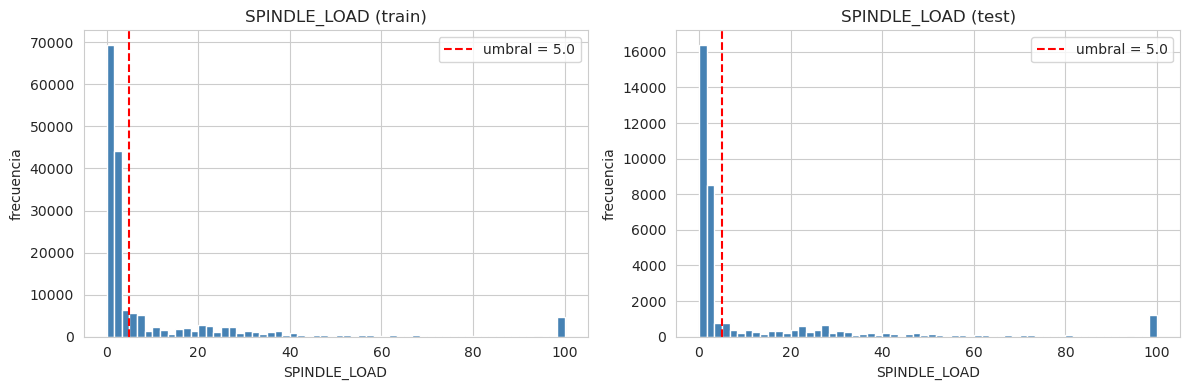

train: total=172132  sin carga=122657 (71.3%)  con carga=49475 (28.7%)
test: total=35832  sin carga=26166 (73.0%)  con carga=9666 (27.0%)


In [3]:
# Distribución de SPINDLE_LOAD para confirmar el umbral
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, df, name in zip(axes, [df_train, df_test], ['train', 'test']):
    ax.hist(df['SPINDLE_LOAD'].clip(0, 100), bins=60, color='steelblue', edgecolor='white')
    ax.axvline(SPINDLE_LOAD_THRESHOLD, color='red', linestyle='--',
               label=f'umbral = {SPINDLE_LOAD_THRESHOLD}')
    ax.set_title(f'SPINDLE_LOAD ({name})')
    ax.set_xlabel('SPINDLE_LOAD'); ax.set_ylabel('frecuencia')
    ax.legend()
plt.tight_layout(); plt.show()

# Resumen
for name, df in [('train', df_train), ('test', df_test)]:
    n = len(df)
    n_no = (df['SPINDLE_LOAD'] <= SPINDLE_LOAD_THRESHOLD).sum()
    n_lo = (df['SPINDLE_LOAD'] >  SPINDLE_LOAD_THRESHOLD).sum()
    print(f'{name}: total={n}  sin carga={n_no} ({100*n_no/n:.1f}%)  con carga={n_lo} ({100*n_lo/n:.1f}%)')


## 3. Helpers de evaluación

Una sola función reutilizable que entrena un modelo en train, predice en test y devuelve un dict de métricas. Distintas combinaciones (target × condición × modelo) se construyen iterando sobre esta función.

In [4]:
# Helpers filter_load, evaluate_single, evaluate_multi viven en src/evaluation.py
# (importados en cell 2 — Sub-paso 3.2, commit 977ce00).
# Esta celda se conserva como placeholder para preservar la numeración de celdas.


## 4. Registro de modelos

Cada modelo se define como una factoría (lambda que devuelve una nueva instancia). El flag `scale` indica si requiere escalado de features (modelos lineales/redes sí; árboles no).

In [5]:
# Registros de modelos generados desde src/evaluation.py
# (make_single_registry/make_multi_registry importados en cell 2 — Sub-paso 3.2, commit 977ce00).
# use_gpu=False fijo: preserva reproducibilidad bit-a-bit del baseline CPU.
SINGLE_MODELS = make_single_registry(use_gpu=False, random_state=RANDOM_STATE)
MULTI_MODELS  = make_multi_registry(use_gpu=False, random_state=RANDOM_STATE)

print(f'Modelos single-output: {list(SINGLE_MODELS)}')
print(f'Modelos multi-output:  {list(MULTI_MODELS)}')
print(f'Condiciones de carga:  {LOAD_CONDITIONS}')


Modelos single-output: ['RandomForest', 'XGBoost', 'LightGBM', 'CatBoost', 'MLPRegressor']
Modelos multi-output:  ['RandomForest', 'XGBoost', 'LightGBM', 'CatBoost', 'MLPRegressor']
Condiciones de carga:  ['all', 'no_load', 'load']


## 5. Experimentos single-output

Bucle anidado sobre (modelo × target × condición). Acumula todos los resultados en una sola lista. Tarda varios minutos.

In [6]:
results = []

for model_name, cfg in SINGLE_MODELS.items():
    for target in TARGET_VARS:
        for load_kind in LOAD_CONDITIONS:
            print(f'  {model_name} | {target} | load={load_kind} ...', end=' ', flush=True)
            r = evaluate_single(
                cfg['factory'], model_name, target, load_kind,
                df_train, df_test, FEATURE_COLS,
                scale=cfg['scale'],
            )
            results.append(r)
            print(f"R²={r['R2']:.4f}  MAE={r['MAE']:.2f}  ({r['fit_s']:.1f}s)")
print(f'\nTotal experimentos single-output: {len(results)}')


  RandomForest | ACCEL_PEAK | load=all ... 

R²=0.8432  MAE=69.54  (10.0s)
  RandomForest | ACCEL_PEAK | load=no_load ... 

R²=0.5691  MAE=45.10  (6.9s)
  RandomForest | ACCEL_PEAK | load=load ... 

R²=0.7969  MAE=133.13  (2.6s)
  RandomForest | ACCEL_RMS | load=all ... 

R²=0.8497  MAE=26.27  (10.3s)
  RandomForest | ACCEL_RMS | load=no_load ... 

...

R²=0.3143  MAE=30.18  (18.8s)
  MLPRegressor | ACCEL_RMS | load=load ... 

R²=0.7321  MAE=64.42  (15.2s)
  MLPRegressor | ACCEL_RMS_FREQ | load=all ... 

R²=0.3479  MAE=105.02  (76.3s)
  MLPRegressor | ACCEL_RMS_FREQ | load=no_load ... 

R²=0.2835  MAE=78.52  (56.1s)
  MLPRegressor | ACCEL_RMS_FREQ | load=load ... 

R²=0.3349  MAE=135.32  (20.6s)

Total experimentos single-output: 45


## 6. Experimentos multi-output

Mismo patrón, predicen los 3 targets simultáneamente. La métrica se reporta por target.

In [7]:
for model_name, cfg in MULTI_MODELS.items():
    for load_kind in LOAD_CONDITIONS:
        print(f'  multi {model_name} | load={load_kind} ...', flush=True)
        rows = evaluate_multi(
            cfg['factory'], model_name, load_kind,
            df_train, df_test, FEATURE_COLS, TARGET_VARS,
            scale=cfg['scale'],
        )
        for r in rows:
            print(f"    {r['target']}: R²={r['R2']:.4f}  MAE={r['MAE']:.2f}  ({r['fit_s']:.1f}s)")
        results.extend(rows)
print(f'\nTotal experimentos acumulados: {len(results)}')


  multi RandomForest | load=all ...


    ACCEL_PEAK: R²=0.8462  MAE=70.13  (10.0s)
    ACCEL_RMS: R²=0.8513  MAE=27.73  (10.0s)
    ACCEL_RMS_FREQ: R²=0.5300  MAE=81.80  (10.0s)
  multi RandomForest | load=no_load ...


    ACCEL_PEAK: R²=0.5831  MAE=46.47  (6.9s)
    ACCEL_RMS: R²=0.5840  MAE=19.03  (6.9s)
    ACCEL_RMS_FREQ: R²=0.4676  MAE=62.24  (6.9s)
  multi RandomForest | load=load ...


    ACCEL_PEAK: R²=0.8046  MAE=133.31  (2.7s)
    ACCEL_RMS: R²=0.8141  MAE=52.96  (2.7s)
    ACCEL_RMS_FREQ: R²=0.4655  MAE=123.15  (2.7s)
  multi XGBoost | load=all ...


    ACCEL_PEAK: R²=0.8463  MAE=69.76  (3.2s)
    ACCEL_RMS: R²=0.8541  MAE=26.76  (3.2s)
    ACCEL_RMS_FREQ: R²=0.5838  MAE=74.84  (3.2s)
  multi XGBoost | load=no_load ...


...

    ACCEL_PEAK: R²=0.5751  MAE=46.85  (3.9s)
    ACCEL_RMS: R²=0.5772  MAE=19.57  (3.9s)
    ACCEL_RMS_FREQ: R²=0.4687  MAE=64.50  (3.9s)
  multi CatBoost | load=load ...


    ACCEL_PEAK: R²=0.7903  MAE=142.92  (2.7s)
    ACCEL_RMS: R²=0.8035  MAE=56.02  (2.7s)
    ACCEL_RMS_FREQ: R²=0.4858  MAE=122.22  (2.7s)
  multi MLPRegressor | load=all ...


    ACCEL_PEAK: R²=0.8018  MAE=85.43  (47.7s)
    ACCEL_RMS: R²=0.7912  MAE=37.31  (47.7s)
    ACCEL_RMS_FREQ: R²=0.3104  MAE=108.35  (47.7s)
  multi MLPRegressor | load=no_load ...


    ACCEL_PEAK: R²=0.3035  MAE=72.67  (34.7s)
    ACCEL_RMS: R²=0.2790  MAE=28.72  (34.7s)
    ACCEL_RMS_FREQ: R²=-0.0859  MAE=108.14  (34.7s)
  multi MLPRegressor | load=load ...


    ACCEL_PEAK: R²=0.7254  MAE=160.04  (19.5s)
    ACCEL_RMS: R²=0.7074  MAE=67.77  (19.5s)
    ACCEL_RMS_FREQ: R²=0.3592  MAE=136.81  (19.5s)

Total experimentos acumulados: 90


## 7. Tabla comparativa y visualización

Convertimos `results` a DataFrame, redondeamos y mostramos pivots por target/carga.

In [8]:
results_df = pd.DataFrame(results)
results_df = results_df.round({'MAE': 3, 'MSE': 3, 'RMSE': 3, 'R2': 4, 'fit_s': 2})

# Guardar tabla maestra
results_path = DATA_DIR / 'models_v2_results.csv'
results_df.to_csv(results_path, index=False)
print(f'Resultados guardados: {results_path}  ({len(results_df)} filas)')
results_df.head(10)


Resultados guardados: <REPO_ROOT>/models_v2_results.csv  (90 filas)


,model,output,target,load,n_train,n_test,MAE,MSE,RMSE,R2,fit_s
0,RandomForest,single,ACCEL_PEAK,all,172132,35832,69.539,18856.989,137.321,0.8432,10.01
1,RandomForest,single,ACCEL_PEAK,no_load,122657,26166,45.098,10613.018,103.020,0.5691,6.94
2,RandomForest,single,ACCEL_PEAK,load,49475,9666,133.130,40483.192,201.204,0.7969,2.61
3,RandomForest,single,ACCEL_RMS,all,172132,35832,26.268,3124.600,55.898,0.8497,10.29
4,RandomForest,single,ACCEL_RMS,no_load,122657,26166,17.077,1767.756,42.045,0.5909,6.88
5,RandomForest,single,ACCEL_RMS,load,49475,9666,53.669,6802.892,82.480,0.8025,2.68
6,RandomForest,single,ACCEL_RMS_FREQ,all,172132,35832,79.307,14941.220,122.234,0.5697,9.75
7,RandomForest,single,ACCEL_RMS_FREQ,no_load,122657,26166,65.829,11110.190,105.405,0.4724,6.58
8,RandomForest,single,ACCEL_RMS_FREQ,load,49475,9666,115.310,25316.440,159.111,0.5107,2.60
9,XGBoost,single,ACCEL_PEAK,all,172132,35832,69.764,18476.318,135.928,0.8463,1.31


In [9]:
# Pivot R² por (target, load) × modelo
pivot_r2 = (
    results_df
    .pivot_table(index=['target', 'load', 'output'], columns='model', values='R2')
    .round(4)
)
print('R² por target/carga/output × modelo:')
pivot_r2


R² por target/carga/output × modelo:


model                          CatBoost  LightGBM  MLPRegressor  RandomForest  \
target         load    output                                                   
ACCEL_PEAK     all     multi     0.8334    0.8513        0.8018        0.8462   
                       single    0.8334    0.8513        0.7074        0.8432   
               load    multi     0.7903    0.8106        0.7254        0.8046   
                       single    0.7903    0.8106        0.6961        0.7969   
               no_load multi     0.5751    0.5961        0.3035        0.5831   
                       single    0.5751    0.5961       -6.1370        0.5691   
ACCEL_RMS      all     multi     0.8388    0.8547        0.7912        0.8513   
                       single    0.8388    0.8547        0.7713        0.8497   
               load    multi     0.8035    0.8094        0.7074        0.8141   
                       single    0.8035    0.8094        0.7321        0.8025   
               no_load multi     0.5772    0.6226        0.2790        0.5840   
                       single    0.5772    0.6226        0.3143        0.5909   
ACCEL_RMS_FREQ all     multi     0.5455    0.5815        0.3104        0.5300   
                       single    0.5455    0.5815        0.3479        0.5697   
               load    multi     0.4858    0.5144        0.3592        0.4655   
                       single    0.4858    0.5144        0.3349        0.5107   
               no_load multi     0.4687    0.5073       -0.0859        0.4676   
                       single    0.4687    0.5073        0.2835        0.4724   

model                          XGBoost  
target         load    output           
ACCEL_PEAK     all     multi    0.8463  
                       single   0.8463  
               load    multi    0.8041  
                       single   0.8041  
               no_load multi    0.5812  
                       single   0.5812  
ACCEL_RMS      all     multi    0.8541  
                       single   0.8541  
               load    multi    0.8051  
                       single   0.8051  
               no_load multi    0.6145  
                       single   0.6145  
ACCEL_RMS_FREQ all     multi    0.5838  
                       single   0.5838  
               load    multi    0.4988  
                       single   0.4988  
               no_load multi    0.5009  
                       single   0.5009

In [10]:
# Top 10 (target, condición, modelo) por R²
top10 = results_df.sort_values('R2', ascending=False).head(10).reset_index(drop=True)
print('Top 10 mejores R²:')
top10[['model', 'output', 'target', 'load', 'R2', 'MAE', 'RMSE', 'n_test']]


Top 10 mejores R²:


,model,output,target,load,R2,MAE,RMSE,n_test
0,LightGBM,single,ACCEL_RMS,all,0.8547,26.500,54.961,35832
1,LightGBM,multi,ACCEL_RMS,all,0.8547,26.500,54.961,35832
2,XGBoost,multi,ACCEL_RMS,all,0.8541,26.763,55.071,35832
3,XGBoost,single,ACCEL_RMS,all,0.8541,26.763,55.071,35832
4,LightGBM,single,ACCEL_PEAK,all,0.8513,66.613,133.696,35832
5,LightGBM,multi,ACCEL_PEAK,all,0.8513,66.613,133.696,35832
6,RandomForest,multi,ACCEL_RMS,all,0.8513,27.733,55.589,35832
7,RandomForest,single,ACCEL_RMS,all,0.8497,26.268,55.898,35832
8,XGBoost,single,ACCEL_PEAK,all,0.8463,69.764,135.928,35832
9,XGBoost,multi,ACCEL_PEAK,all,0.8463,69.764,135.928,35832


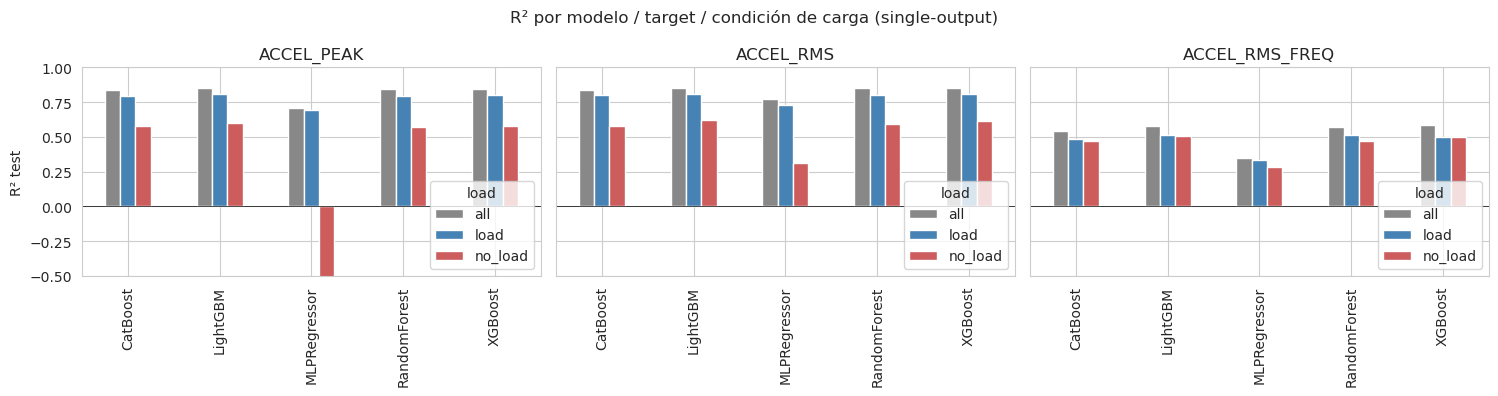

In [11]:
# Bar chart: R² por modelo (single-output, condition='all')
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, target in zip(axes, TARGET_VARS):
    sub = results_df[(results_df['output']=='single') & (results_df['target']==target)]
    sub_pivot = sub.pivot(index='model', columns='load', values='R2')
    sub_pivot.plot(kind='bar', ax=ax, color=['#888', '#4682B4', '#CD5C5C'])
    ax.set_title(f'{target}'); ax.set_ylim(-0.5, 1.0)
    ax.set_ylabel('R² test'); ax.axhline(0, color='black', linewidth=0.5)
    ax.legend(title='load', loc='lower right')
    ax.set_xlabel('')
plt.suptitle('R² por modelo / target / condición de carga (single-output)')
plt.tight_layout(); plt.show()


## 8. Diagnóstico del mejor modelo

Para el mejor (target × condición) según R², reentrenamos y mostramos predicho vs real + residuales.

Mejor combinación según R²:
model       LightGBM
output        single
target     ACCEL_RMS
load             all
n_train       172132
n_test         35832
MAE             26.5
MSE         3020.739
RMSE          54.961
R2            0.8547
fit_s           3.43
Name: 21, dtype: object



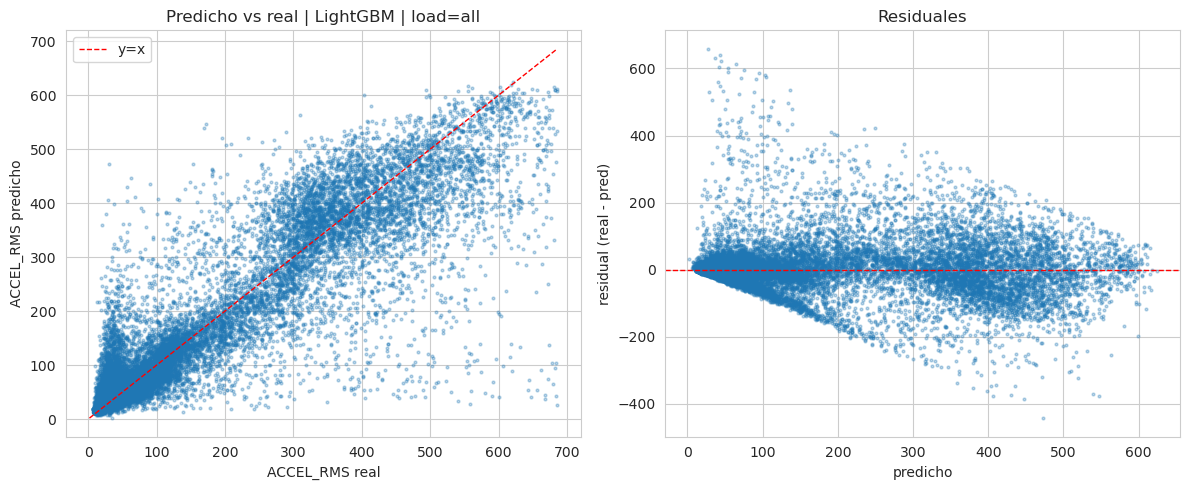

Resumen residuales: mean=0.325  std=54.960  p5=-70.65  p95=76.75


In [12]:
best = results_df.sort_values('R2', ascending=False).iloc[0]
print(f'Mejor combinación según R²:\n{best}\n')

cfg = SINGLE_MODELS[best['model']] if best['output']=='single' else MULTI_MODELS[best['model']]
target = best['target']; load_kind = best['load']

tr = filter_load(df_train, load_kind)
te = filter_load(df_test,  load_kind)
X_tr, X_te = tr[FEATURE_COLS].values, te[FEATURE_COLS].values
y_tr, y_te = tr[target].values, te[target].values
if cfg['scale']:
    sc = StandardScaler(); X_tr = sc.fit_transform(X_tr); X_te = sc.transform(X_te)

if best['output']=='single':
    model = cfg['factory'](); model.fit(X_tr, y_tr); y_pred = model.predict(X_te)
else:
    Y_tr = tr[TARGET_VARS].values
    model = cfg['factory'](); model.fit(X_tr, Y_tr)
    Y_pred = model.predict(X_te)
    y_pred = Y_pred[:, TARGET_VARS.index(target)]

residuals = y_te - y_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# Predicho vs real
ax = axes[0]
ax.scatter(y_te, y_pred, s=4, alpha=0.3)
lim = [min(y_te.min(), y_pred.min()), max(y_te.max(), y_pred.max())]
ax.plot(lim, lim, 'r--', linewidth=1, label='y=x')
ax.set_xlabel(f'{target} real'); ax.set_ylabel(f'{target} predicho')
ax.set_title(f'Predicho vs real | {best["model"]} | load={load_kind}')
ax.legend()
# Residuales
ax = axes[1]
ax.scatter(y_pred, residuals, s=4, alpha=0.3)
ax.axhline(0, color='red', linestyle='--', linewidth=1)
ax.set_xlabel('predicho'); ax.set_ylabel('residual (real - pred)')
ax.set_title('Residuales')
plt.tight_layout(); plt.show()

print(f'Resumen residuales: mean={residuals.mean():.3f}  std={residuals.std():.3f}  '
      f'p5={np.percentile(residuals,5):.2f}  p95={np.percentile(residuals,95):.2f}')


## 9. Conclusiones automáticas

Resumen textual generado a partir de la tabla de resultados — útil para citar en el proyecto.

In [13]:
# Mejor modelo por target (condición 'all')
all_single = results_df[(results_df['output']=='single') & (results_df['load']=='all')]
print('=== Mejor modelo por target (single-output, condición all) ===')
for t in TARGET_VARS:
    sub = all_single[all_single['target']==t].sort_values('R2', ascending=False)
    if len(sub):
        b = sub.iloc[0]
        print(f'  {t:18s}: {b["model"]:14s} R²={b["R2"]:.4f}  MAE={b["MAE"]:.2f}  RMSE={b["RMSE"]:.2f}')

print('\n=== Comparación con/sin carga del husillo (mejor R² por condición) ===')
for kind in ['no_load', 'load']:
    sub = results_df[(results_df['output']=='single') & (results_df['load']==kind)].sort_values('R2', ascending=False).head(3)
    print(f'\nload={kind} top-3:')
    for _, r in sub.iterrows():
        print(f'  {r["model"]:14s} {r["target"]:18s} R²={r["R2"]:.4f}  n_test={r["n_test"]}')

print('\n=== Single vs Multi-output (RandomForest, condición all) ===')
for t in TARGET_VARS:
    s = results_df[(results_df['model']=='RandomForest')&(results_df['target']==t)&(results_df['load']=='all')]
    s_single = s[s['output']=='single']
    s_multi  = s[s['output']=='multi']
    if len(s_single) and len(s_multi):
        print(f'  {t:18s} single R²={s_single.iloc[0]["R2"]:.4f}   multi R²={s_multi.iloc[0]["R2"]:.4f}')


=== Mejor modelo por target (single-output, condición all) ===
  ACCEL_PEAK        : LightGBM       R²=0.8513  MAE=66.61  RMSE=133.70
  ACCEL_RMS         : LightGBM       R²=0.8547  MAE=26.50  RMSE=54.96
  ACCEL_RMS_FREQ    : XGBoost        R²=0.5838  MAE=74.84  RMSE=120.22

=== Comparación con/sin carga del husillo (mejor R² por condición) ===

load=no_load top-3:
  LightGBM       ACCEL_RMS          R²=0.6226  n_test=26166
  XGBoost        ACCEL_RMS          R²=0.6145  n_test=26166
  LightGBM       ACCEL_PEAK         R²=0.5961  n_test=26166

load=load top-3:
  LightGBM       ACCEL_PEAK         R²=0.8106  n_test=9666
  LightGBM       ACCEL_RMS          R²=0.8094  n_test=9666
  XGBoost        ACCEL_RMS          R²=0.8051  n_test=9666

=== Single vs Multi-output (RandomForest, condición all) ===
  ACCEL_PEAK         single R²=0.8432   multi R²=0.8462
  ACCEL_RMS          single R²=0.8497   multi R²=0.8513
  ACCEL_RMS_FREQ     single R²=0.5697   multi R²=0.5300
